# Seq2Seq Text-to-Python Code Generation


In [ ]:
# Check GPU availability
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No GPU! Go to: Runtime → Change runtime type → GPU")

CUDA Available: True
GPU: Tesla T4
GPU Memory: 15.64 GB


## Setup Method


In [ ]:
# Option B: Clone from GitHub (faster, if repo is pushed)
# Run this INSTEAD of mounting Drive if you want to use GitHub
!git clone https://github.com/thabir303/seq2seq.git
%cd seq2seq
!pwd

Cloning into 'seq2seq'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 40 (delta 9), reused 39 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 47.26 KiB | 15.75 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/seq2seq/seq2seq/seq2seq
/content/seq2seq/seq2seq/seq2seq


In [ ]:
# Install dependencies
!pip install -q datasets transformers nltk tqdm matplotlib seaborn

# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
print("✓ Dependencies installed")

✓ Dependencies installed


In [ ]:
# Clean old checkpoints (different vocab size)
!rm -f checkpoints/*.pt checkpoints/*.pkl
print("✓ Cleaned old checkpoints")

✓ Cleaned old checkpoints


##  Train All Models


In [ ]:
!python train.py --model all --epochs 15 --resume

Seq2Seq Text-to-Python Code Generation
Device: cuda
Epochs: 15
Batch Size: 64
Learning Rate: 0.001
Training Size: 8000

Loading datasets...
Loading CodeSearchNet Python dataset (train)...
Loaded 8000 examples from train split
Loading CodeSearchNet Python dataset (validation)...
Error loading dataset: Unknown split "validation". Should be one of ['train'].
Attempting alternative loading method...
Loaded 800 examples
Loading CodeSearchNet Python dataset (test)...
Error loading dataset: Unknown split "test". Should be one of ['train'].
Attempting alternative loading method...
Loaded 800 examples
Building vocabularies...
Tokenizing: 100% 8000/8000 [00:00<00:00, 19205.72it/s]
Built source vocabulary with 17882 tokens
Built target vocabulary with 20000 tokens
Preprocessing data: 100% 8000/8000 [00:00<00:00, 24182.57it/s]
Preprocessing data: 100% 800/800 [00:00<00:00, 24213.74it/s]
Preprocessing data: 100% 800/800 [00:00<00:00, 26700.86it/s]

Dataset Statistics:
  Training examples: 8000
  Va

## Evaluation

In [ ]:
!python evaluate.py --model all

Seq2Seq Model Evaluation
Device: cuda

Loading test data...
Loading CodeSearchNet Python dataset (train)...
Loaded 8000 examples from train split
Loading CodeSearchNet Python dataset (validation)...
Error loading dataset: Unknown split "validation". Should be one of ['train'].
Attempting alternative loading method...
Loaded 800 examples
Loading CodeSearchNet Python dataset (test)...
Error loading dataset: Unknown split "test". Should be one of ['train'].
Attempting alternative loading method...
Loaded 800 examples
Building vocabularies...
Tokenizing: 100% 8000/8000 [00:00<00:00, 20568.87it/s]
Built source vocabulary with 17882 tokens
Built target vocabulary with 20000 tokens
Preprocessing data: 100% 8000/8000 [00:00<00:00, 23481.78it/s]
Preprocessing data: 100% 800/800 [00:00<00:00, 23014.33it/s]
Preprocessing data: 100% 800/800 [00:00<00:00, 25260.42it/s]

Dataset Statistics:
  Training examples: 8000
  Validation examples: 800
  Test examples: 800
  Source vocabulary size: 17882
  Ta

## Attention Visualization

In [16]:
!python visualize_attention.py --num_examples 5

Attention Visualization
Device: cuda
Number of examples: 5

Loading data...
Loading CodeSearchNet Python dataset (train)...
Loaded 8000 examples from train split
Loading CodeSearchNet Python dataset (validation)...
Error loading dataset: Unknown split "validation". Should be one of ['train'].
Attempting alternative loading method...
Loaded 800 examples
Loading CodeSearchNet Python dataset (test)...
Error loading dataset: Unknown split "test". Should be one of ['train'].
Attempting alternative loading method...
Loaded 800 examples
Building vocabularies...
Tokenizing: 100% 8000/8000 [00:00<00:00, 20721.50it/s]
Built source vocabulary with 17882 tokens
Built target vocabulary with 20000 tokens
Preprocessing data: 100% 8000/8000 [00:00<00:00, 24599.83it/s]
Preprocessing data: 100% 800/800 [00:00<00:00, 23184.96it/s]
Preprocessing data: 100% 800/800 [00:00<00:00, 26178.61it/s]

Dataset Statistics:
  Training examples: 8000
  Validation examples: 800
  Test examples: 800
  Source vocabulary 

## View Results

{
  "vanilla_rnn": {
    "model": "vanilla_rnn",
    "bleu_score": 0.0059523252438494455,
    "token_accuracy": 0.17978792858911727,
    "exact_match": 0.0,
    "syntax_accuracy": 0.0,
    "error_types": {
      "syntax_error": 800,
      "indentation_error": 0,
      "other_error": 0
    },
    "error_analysis": {
      "missing_rate": 0.7692055027436433,
      "extra_rate": 1.0057771079681583,
      "wrong_rate": 0.8188422598346086
    },
    "metrics_by_length": {
      "0-10": {
        "bleu": 0.006435160971799945,
        "count": 159
      },
      "11-20": {
        "bleu": 0.0002925713276150206,
        "count": 146
      },
      "21-30": {
        "bleu": 0.00032589836118303273,
        "count": 96
      },
      "31-40": {
        "bleu": 0.0003313235975877096,
        "count": 61
      },
      "41-50": {
        "bleu": 0.00031796819274408145,
        "count": 338
      }
    }
  },
  "lstm": {
    "model": "lstm",
    "bleu_score": 0.03623606902891304,
    "token_accurac

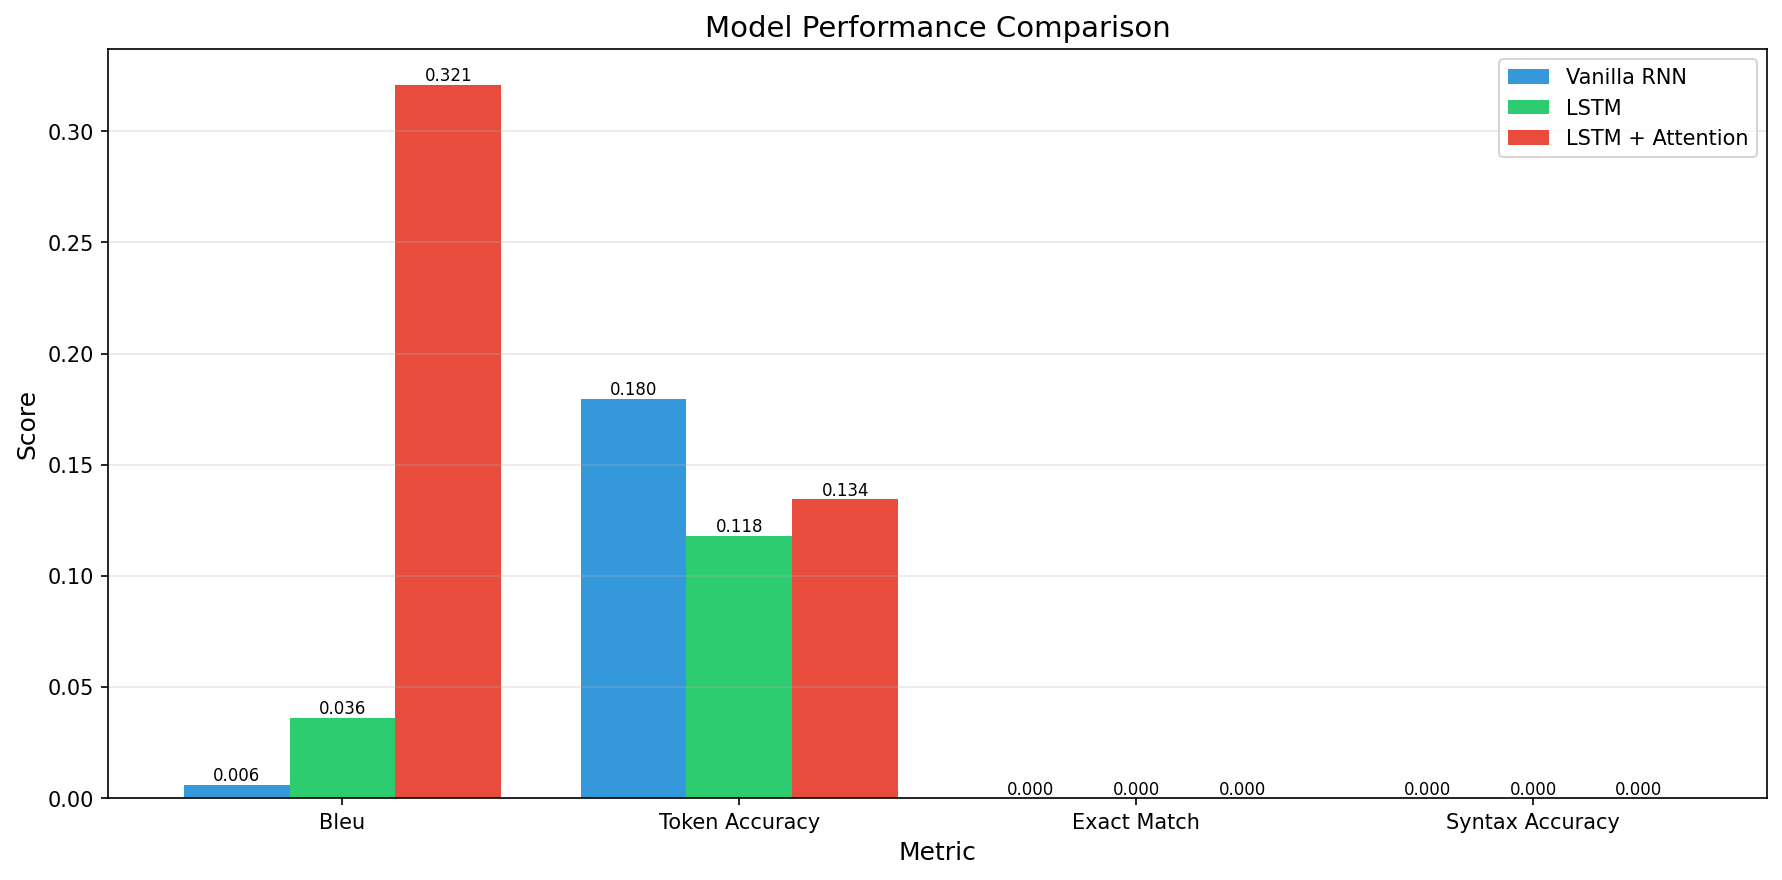

In [17]:
# Display evaluation results
import json
from IPython.display import display, Image

# Show metrics
with open('results/all_models_evaluation.json', 'r') as f:
    results = json.load(f)
    print(json.dumps(results, indent=2))

# Show comparison plot
display(Image('visualizations/model_comparison.png'))

In [18]:
# Check what was created
!echo "=== Checkpoints ==="
!ls -lh checkpoints/*.pt 2>/dev/null || echo "No checkpoints yet"
!echo "\n=== Results ==="
!ls -lh results/*.json 2>/dev/null || echo "No results yet"
!echo "\n=== Visualizations ==="
!ls -lh visualizations/*.png 2>/dev/null || echo "No visualizations yet"

=== Checkpoints ===
-rw-r--r-- 1 root root 375M Feb 13 16:46 checkpoints/lstm_attention_best.pt
-rw-r--r-- 1 root root 375M Feb 13 16:34 checkpoints/lstm_attention_epoch_10.pt
-rw-r--r-- 1 root root 375M Feb 13 16:46 checkpoints/lstm_attention_epoch_15.pt
-rw-r--r-- 1 root root 375M Feb 13 16:22 checkpoints/lstm_attention_epoch_5.pt
-rw-r--r-- 1 root root 375M Feb 13 16:46 checkpoints/lstm_attention_latest.pt
-rw-r--r-- 1 root root 182M Feb 13 16:10 checkpoints/lstm_best.pt
-rw-r--r-- 1 root root 182M Feb 13 16:02 checkpoints/lstm_epoch_10.pt
-rw-r--r-- 1 root root 182M Feb 13 16:10 checkpoints/lstm_epoch_15.pt
-rw-r--r-- 1 root root 182M Feb 13 15:53 checkpoints/lstm_epoch_5.pt
-rw-r--r-- 1 root root 182M Feb 13 16:10 checkpoints/lstm_latest.pt
-rw-r--r-- 1 root root 173M Feb 13 15:43 checkpoints/vanilla_rnn_best.pt
-rw-r--r-- 1 root root 173M Feb 13 15:37 checkpoints/vanilla_rnn_epoch_10.pt
-rw-r--r-- 1 root root 173M Feb 13 15:45 checkpoints/vanilla_rnn_epoch_15.pt
-rw-r--r-- 1 root